# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from phik import phik_matrix
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.model_selection import cross_validate

In [2]:
RANDOM_STATE = 42

In [3]:
data = pd.read_csv('coffee_churn_dataset.csv', sep=',', decimal='.')

In [4]:
display(data)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10445,user_05734,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,arabica,...,1.0,3.149287,5.180760,NaN,summer,2.0,android,NaN,NaN,0
10446,user_05191,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,blend,...,1.0,5.144074,2.438754,NaN,winter,17.0,ios,1.0,geo_36,0
10447,user_05390,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,arabica,...,1.0,3.975122,5.018790,1.0,winter,7.0,ios,0.0,geo_12,0
10448,user_00860,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,arabica,...,0.0,4.564480,2.024267,1.0,autumn,NaN,ios,0.0,geo_3,0


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

## Этап 2. Первичный анализ данных
1. Признаки в датасете:
    - user_id — идентификатор пользователя. В датасете представлена информация о 10450 пользователях
    - days_since_last_order — количество дней, прошедших с последнего заказа.
    - order_frequency_month — среднее число заказов в месяц.
    - order_frequency_week — среднее число заказов в неделю.
    - avg_order_value — средний чек, в рублях.
    - median_order_value — медианный чек, в рублях.
    - total_spent_last_month — сумма заказов за последний месяц.
    - total_spent_last_week — сумма заказов за последнюю неделю.
    - discount_usage_rate — доля заказов со скидкой за последний месяц.
    - last_coffee_type — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
    - preferred_roast — предпочитаемый тип обжарки.
    - milk_preference — предпочитаемый тип молока.
    - seasonal_menu_tried — отметка о том, пробовал ли пользователь новейшее сезонное меню.
    - coffee_bean_origin — страна происхождения зерна.
    - last_drink_size — размер последнего заказа, совершённого на момент сбора данных.
    - subscription_status — тип подписки пользователя.
    - app_opens_per_week — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
    - notifications_enabled — включены ли у пользователя уведомления.
    - review_rating_last_10 — средняя оценка последних на момент сбора данных десяти заказов клиента.
    - review_rating_last_1 — оценка последнего на момент сбора данных заказа клиента.
    - app_crashes_last_month — сколько раз приложение зависало за последний месяц.
    - seasons — текущее время года.
    - days_since_last_promo — сколько дней прошло с последнего использования акции или промокода.
    - phone_type — тип устройства, с которого пользователь чаще всего совершал покупки.
    - coffee_preference_change — менялись ли вкусовые предпочтения пользователя.
    - geo_id — идентификатор региона пользователя.
 
**Признаки агрегированы за последние 4 недели**

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [6]:
print(f'{data['churn'].unique()} - значения целевой переменной (0 - пользователь не перестал пользоваться сервисом, 1 - пользователь перестал пользоваться сервисом)')

[1 0] - значения целевой переменной (0 - пользователь не перестал пользоваться сервисом, 1 - пользователь перестал пользоваться сервисом)


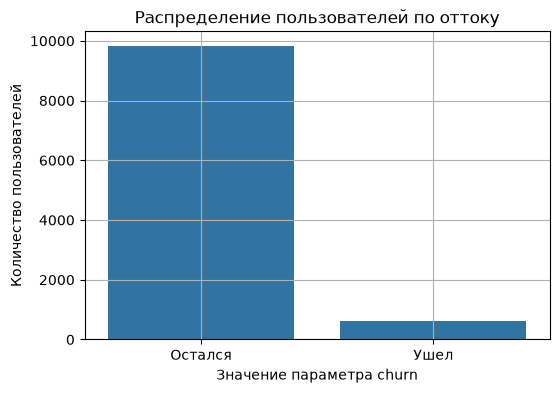

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data = data, x= 'churn')
plt.xlabel("Значение параметра churn")
plt.ylabel("Количество пользователей")
plt.xticks([0,1], ['Остался','Ушел'])
plt.title('Распределение пользователей по оттоку')
plt.grid(True)
plt.show()

In [8]:
data.groupby('churn')['user_id'].count()

churn
0    9821
1     629
Name: user_id, dtype: int64

2. 
    - Целевой переменной является параметр churn, который показывает остался пользователь (значение 0) или перестал пользоваться сервисом (значение 1)
    - Из графика видно, что распределение классов не сбалансированно (9821 пользователь остался пользоваться платформой, 629 пользователей - престали пользоваться платформой)

3. **Важные признаки**

Практически все признаки (кроме идентификатора пользователя) потенциально могут влиять на вероятность оттока. Их можно разделить на группы:
- Активность пользователя:
    - days_since_last_order
    - order_frequency_month
    - order_frequency_week
    - app_opens_per_week
- Финансовые показатели:
    - avg_order_value
    - median_order_value
    - total_spent_last_month
    - total_spent_last_week
    - discount_usage_rate
- Предпочтения пользователя:
    - last_coffee_type
    - preferred_roast
    - milk_preference
    - coffee_bean_origin
    - last_drink_size
    - coffee_preference_change
- Взаимодействие с сервисом:
    - subscription_status
    - seasonal_menu_tried
    - notifications_enabled
    - days_since_last_promo
- Качество сервиса:
    - review_rating_last_10
    - review_rating_last_1
    - app_crashes_last_month
- Контекст:
    - seasons
    - phone_type
    - geo_location

Все эти признаки имеют потенциальную связь с тем, останется пользователь или уйдет

**Какие признаки можно удалить**
- user_id - уникальный идентификатор пользователя, который не содержит информацию о поведении клиента и уникален для каждой строки 

**Пока не стоит удалять остальные признаки**

- Например, могут показаться похожими:
    - order_frequency_month
    - order_frequency_week
или
    - avg_order_value
    - median_order_value

Но без анализа нельзя утверждать, что один из них лишний. Требуется сначала проверить корреляцию данных признаков.

 ### 4.  **Обработка некорректных значений и пропусков**

In [9]:
missing = (
    data.isna()
        .sum()
        .to_frame('Количество пропусков')
)

missing['Доля, %'] = (
    missing['Количество пропусков'] / len(data) * 100
).round(2)

missing.sort_values('Доля, %', ascending=False)

,Количество пропусков,"Доля, %"
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63


- В датасете присутствуют пропущенные значения практически во всех признаках, однако их доля не превышает 9,5%. Максимальное количество пропусков наблюдается в признаке seasonal_menu_tried (9,46%), минимальное — в geo_location (1,05%). Целевая переменная churn не содержит пропусков.

**Поскольку количество наблюдается в ольшинстве столбцов, удаление строк приведет к потере >10% данных, что может негативно сказаться на качестве обучения модели, а также еще более дисбалансировать распределение пользователей по целевой перменной. Поэтому предпочтительно использовать заполнение пропусков.**

In [10]:
data.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


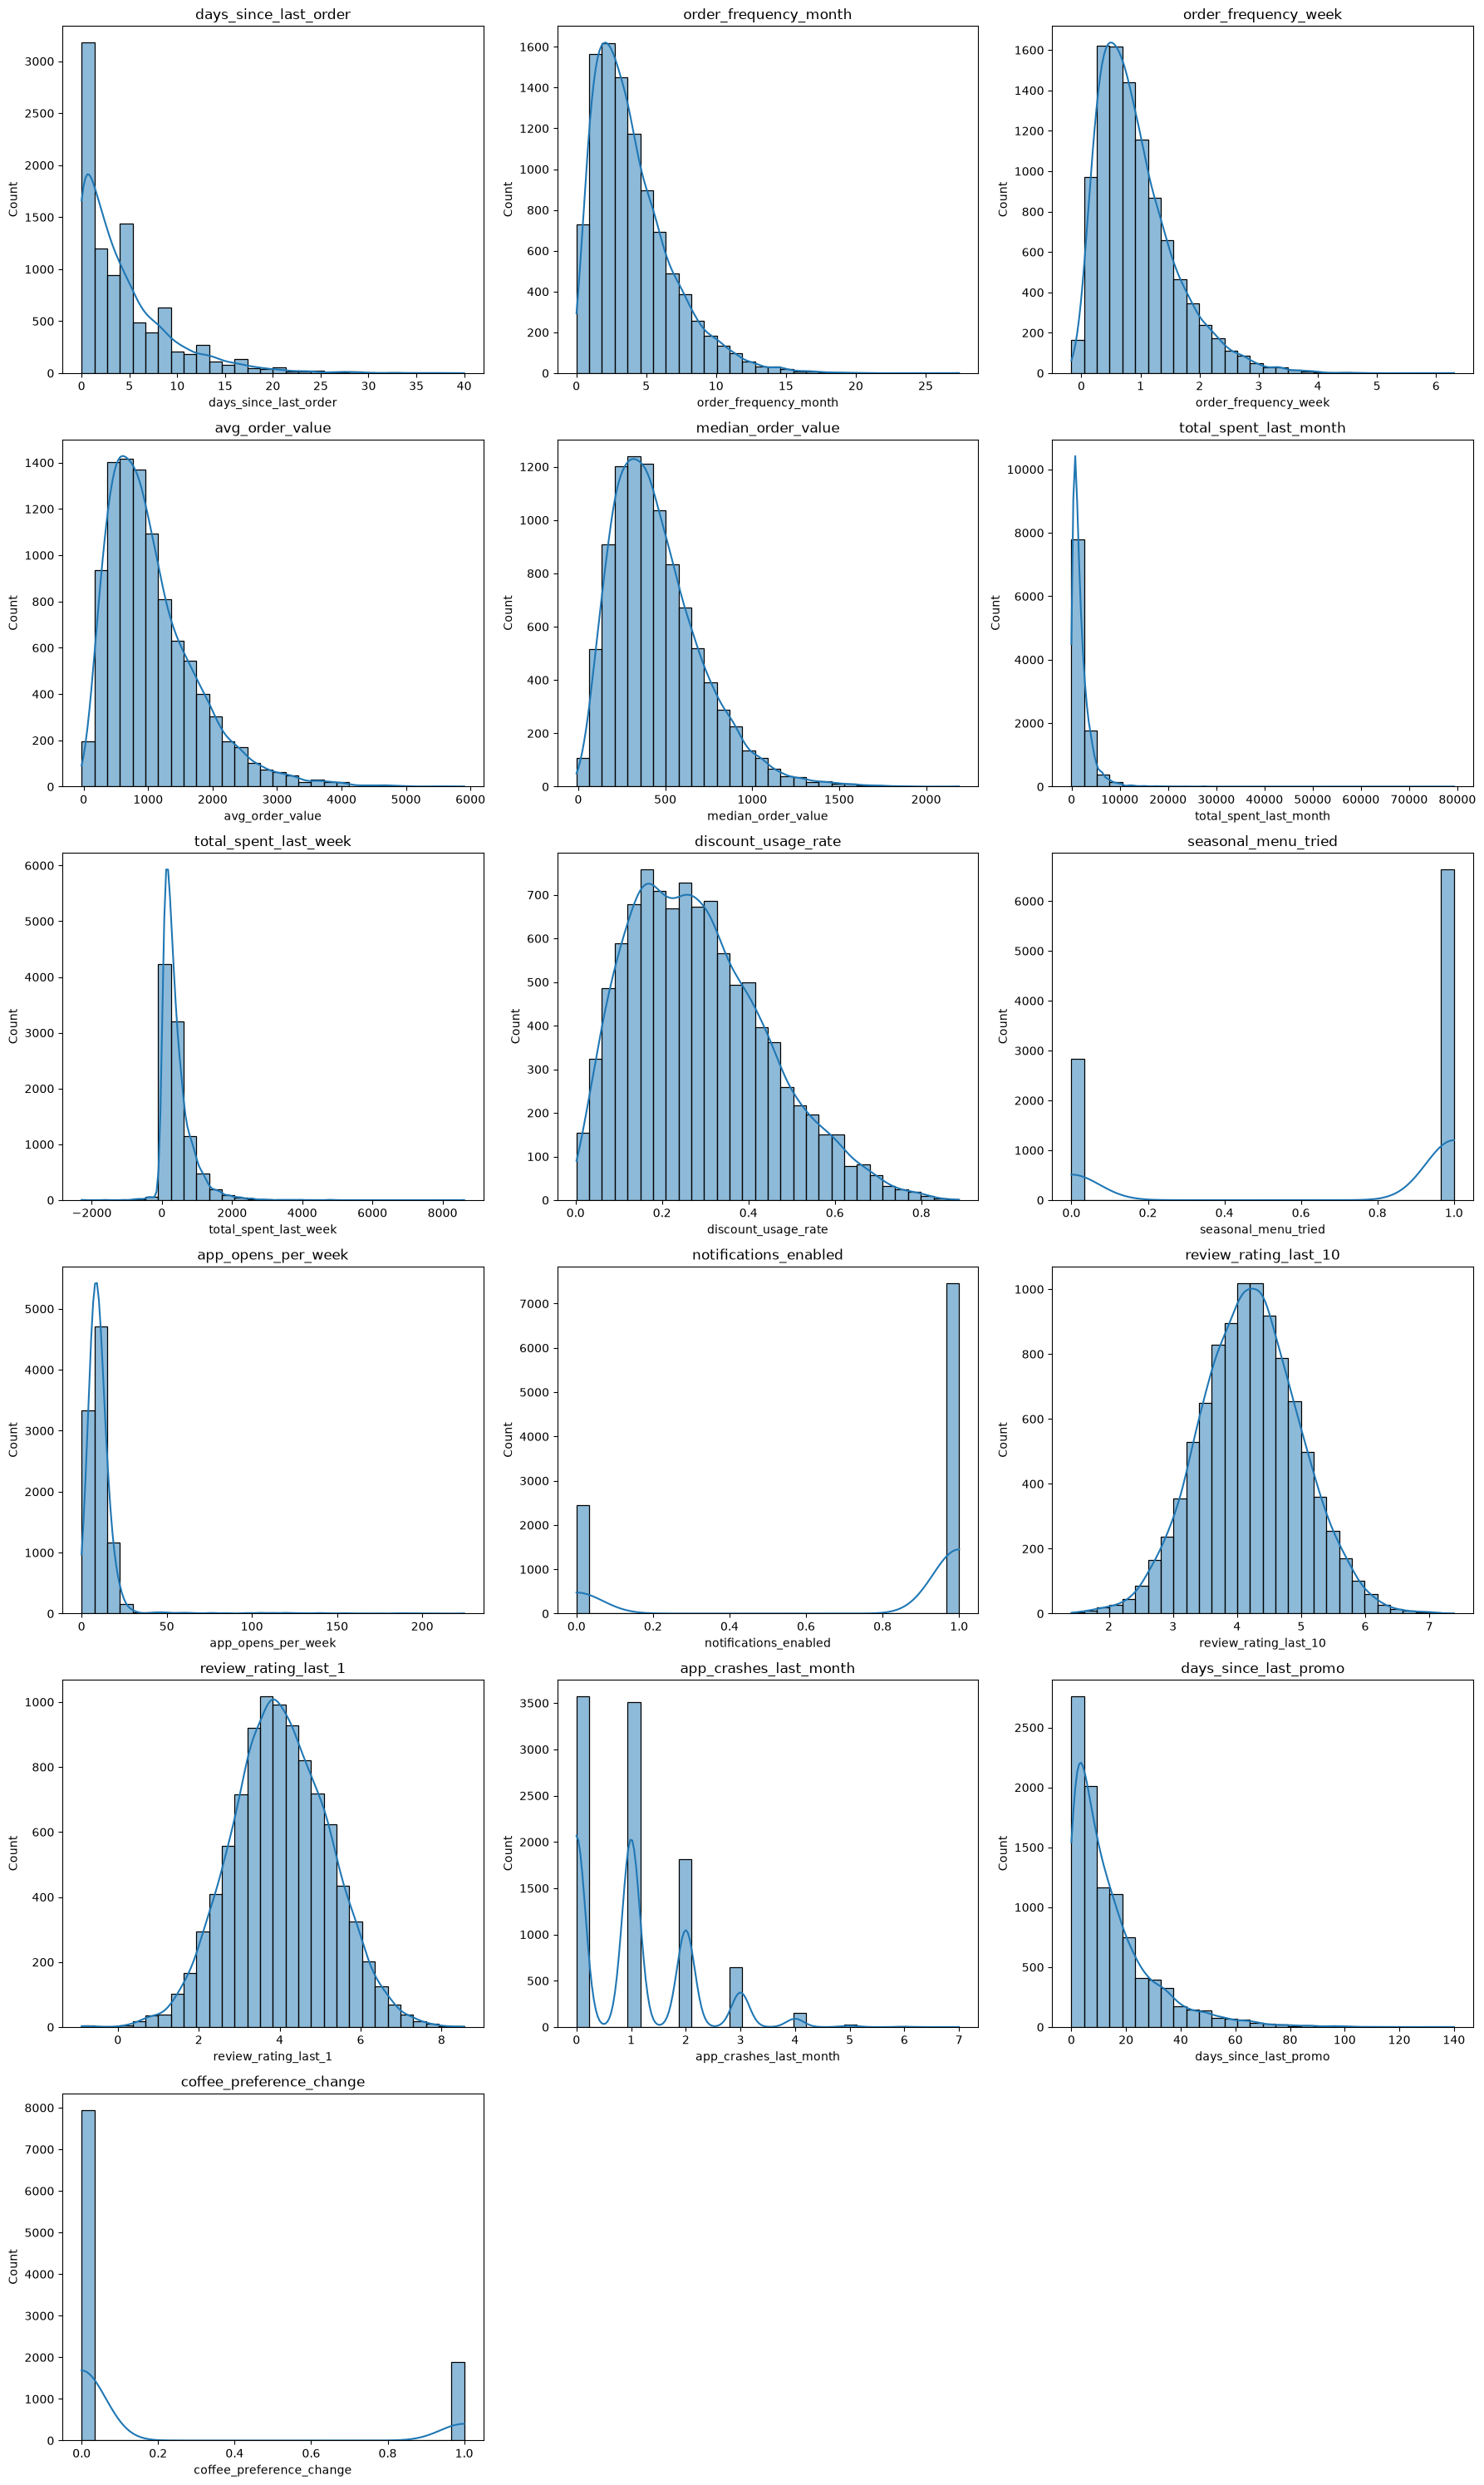

In [11]:
# Числовые признаки (без целевой переменной)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('churn')

# Размер сетки
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()



#### Анализ числовых признаков

Перед заполнением пропусков были построены гистограммы распределения числовых признаков и рассчитаны основные статистики.

В ходе анализа было обнаружено, что часть признаков содержит отрицательные значения, которые противоречат их смыслу. Например:

- `days_since_last_order` — количество дней с момента последнего заказа;
- `avg_order_value` — средний чек;
- `median_order_value` — медианный чек;
- `total_spent_last_month` — сумма заказов за последний месяц;
- `total_spent_last_week` — сумма заказов за последнюю неделю;
- `review_rating_last_1` — оценка последнего заказа.

Для подобных признаков отрицательные значения невозможны и, вероятнее всего, являются следствием ошибок формирования данных. Чтобы не удалять наблюдения, такие значения будут ограничены снизу нулем с помощью функции `np.clip(lower=0)`.

После корректировки данных будут обработаны пропущенные значения.

Большинство числовых признаков имеют выраженную правостороннюю асимметрию и содержат выбросы. Для таких распределений использование среднего значения может привести к смещению оценки центра распределения. Поэтому пропуски в числовых признаках будут заполнены медианой.

Несмотря на то что распределение признаков `review_rating_last_10` и `review_rating_last_1` близко к нормальному, для единообразия обработки данных также будет использовано заполнение медианой. При симметричном распределении медиана и среднее дают близкие значения, поэтому качество данных при этом не ухудшается.

#### Числовые признаки

Следующие признаки были заполнены медианой:

- `days_since_last_order`
- `order_frequency_month`
- `order_frequency_week`
- `avg_order_value`
- `median_order_value`
- `total_spent_last_month`
- `total_spent_last_week`
- `discount_usage_rate`
- `app_opens_per_week`
- `review_rating_last_10`
- `review_rating_last_1`
- `app_crashes_last_month`
- `days_since_last_promo`

Бинарные признаки будут заполнены наиболее часто встречающимся значением (модой). Такой подход позволяет сохранить объем выборки и не вносит искусственных категорий в данные.

#### Бинарные признаки

Следующие признаки содержат только значения 0 и 1, поэтому их пропуски были заполнены наиболее часто встречающимся значением (модой):

- `seasonal_menu_tried`
- `notifications_enabled`
- `coffee_preference_change`

In [12]:
print(f'{data['geo_location'].nunique()} - количество уникальных идентификаторов местоположения пользователя')

100 - количество уникальных идентификаторов местоположения пользователя


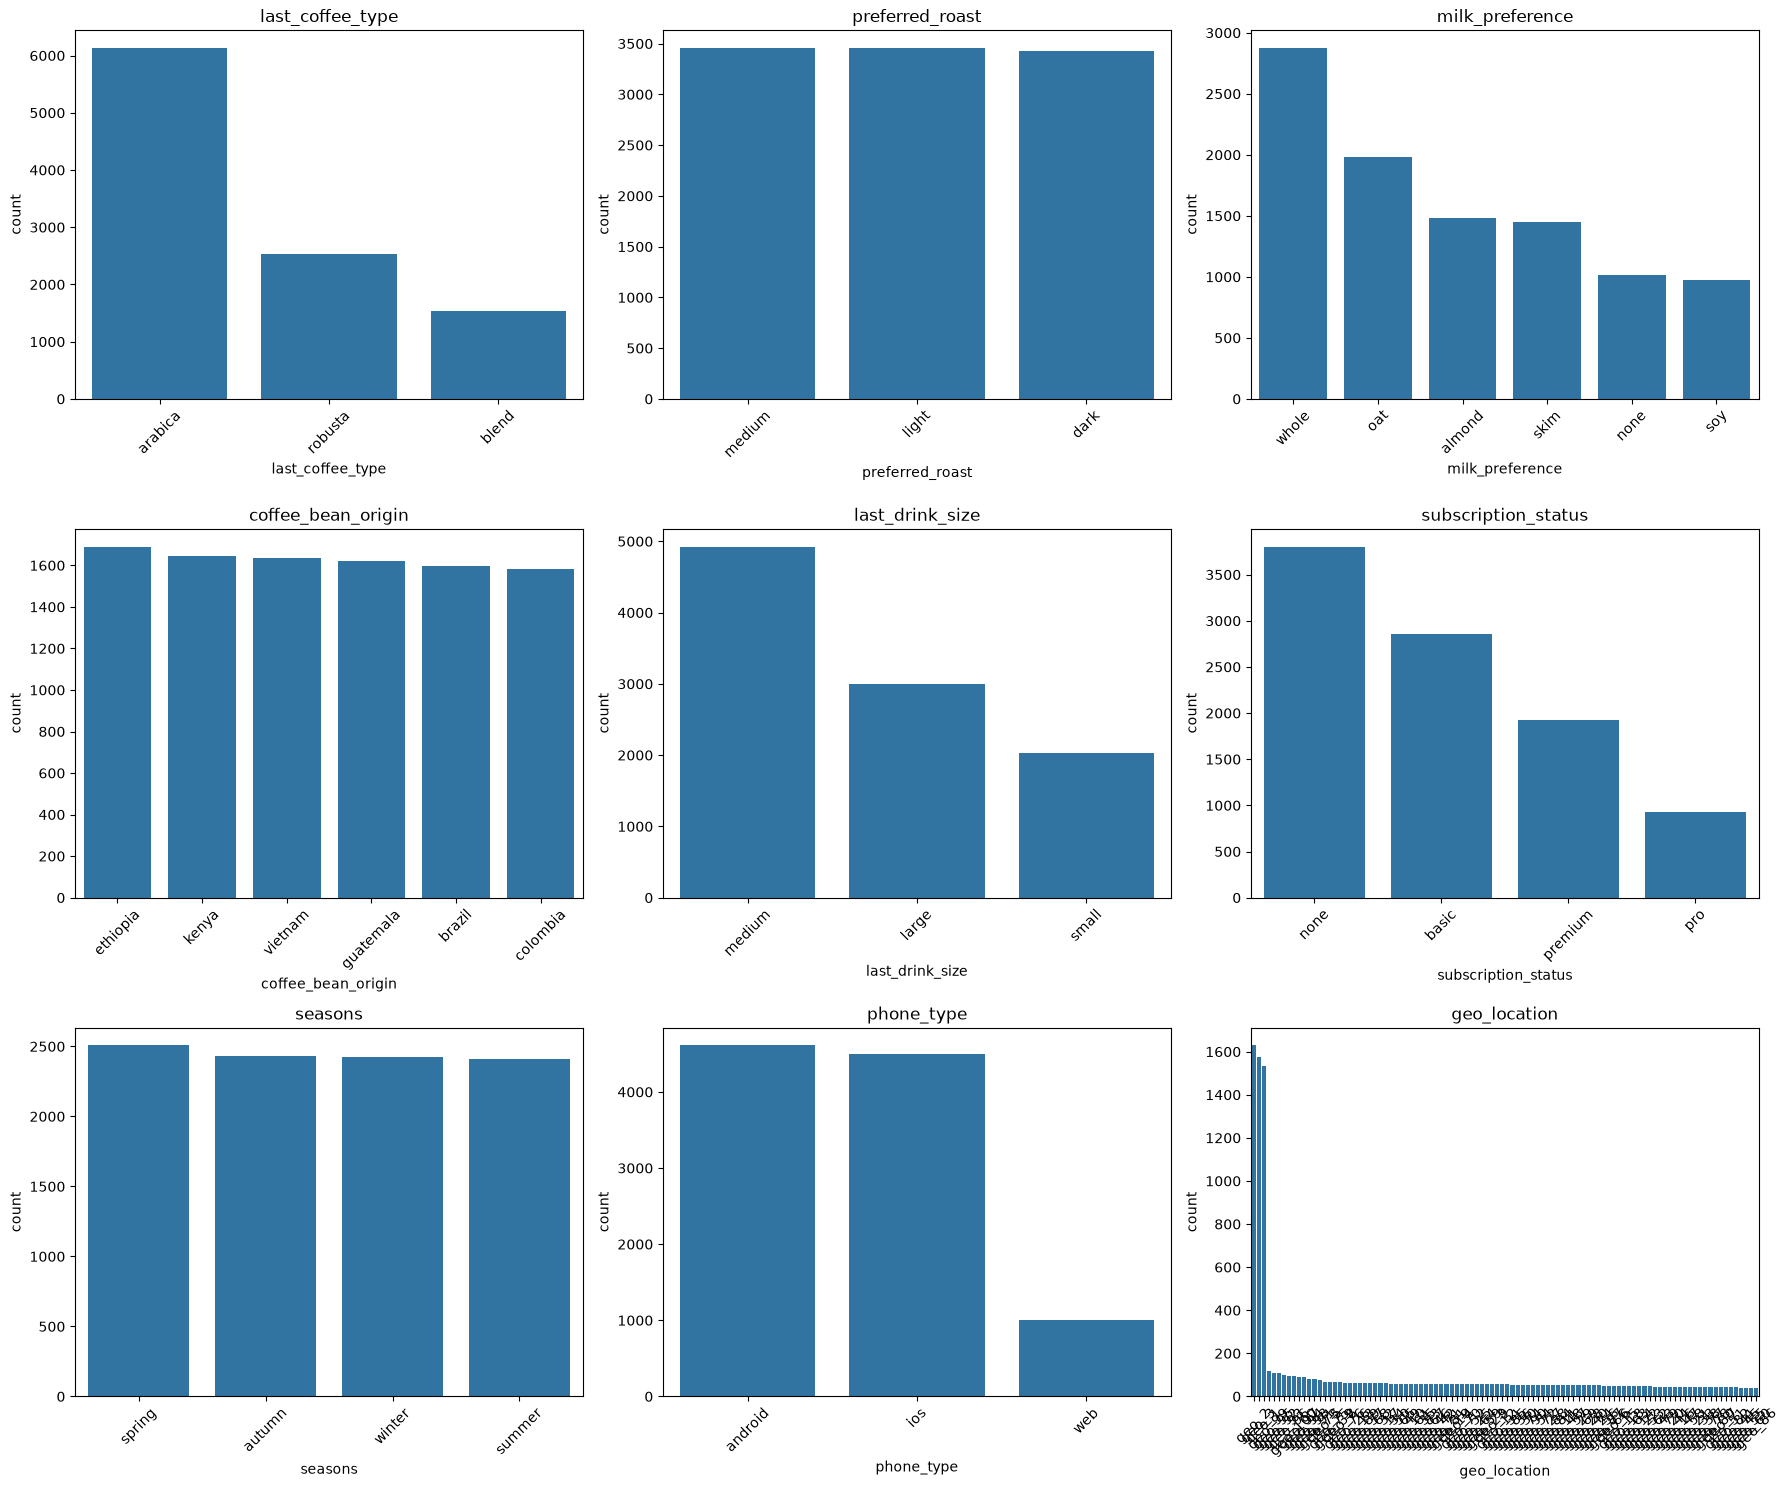

In [13]:
categorical_cols = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]




fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Обработка пропусков в категориальных признаках

Для категориальных признаков была выбрана индивидуальная стратегия заполнения пропусков в зависимости от распределения значений и доли пропусков.

- **`last_coffee_type`** — пропуски заполнены наиболее часто встречающимся значением (модой), поскольку признак имеет явно выраженного лидера (`arabica`), а доля пропусков составляет всего 2.47%.

- **`preferred_roast`** — значения распределены практически равномерно между тремя категориями, а доля пропусков составляет всего 1.11%. В связи с небольшим количеством пропусков соответствующие строки были удалены.

- **`milk_preference`** — пропуски заполнены модой (`whole`), так как данная категория встречается значительно чаще остальных.

- **`coffee_bean_origin`** — распределение между категориями практически равномерное, поэтому заполнение модой могло бы искусственно увеличить долю одной из стран происхождения. Пропуски заполнены отдельной категорией `Unknown`.

- **`last_drink_size`** — пропуски заполнены модой (`medium`), поскольку данная категория встречается значительно чаще остальных.

- **`subscription_status`** — признак потенциально является важным для прогнозирования оттока, а доля пропусков достаточно велика (8.98%). Чтобы не терять наблюдения и не искажать распределение существующих категорий, пропуски заполнены значением `Unknown`.

- **`seasons`** — времена года представлены практически равномерно, поэтому заполнение модой привело бы к искусственному увеличению одной из категорий. Пропуски заполнены значением `Unknown`.

- **`phone_type`** — пропусков всего 3.22%, при этом основные категории (`android` и `ios`) представлены практически одинаково. В связи с небольшим количеством пропусков соответствующие строки были удалены.

- **`geo_location`** — признак содержит 100 различных регионов, при этом пропуски составляют всего 1.05%. Поскольку доля пропусков незначительна, а заполнение модой привело бы к искусственному увеличению наиболее распространенного региона, данный признак было решено оставить без изменений.

### 5. **Анализ категориальных признаков**
#### Кодирование признаков 

**В датасете присутствуют две группы категориальных признаков:**
- `seasonal_menu_tried`
- `notifications_enabled`
- `coffee_preference_change`

Данные признаки принимают только два значения (`0` и `1`) и уже представлены в числовом формате. Дополнительного кодирования они не требуют и могут быть непосредственно использованы при обучении модели.

**Номинальные признаки:**
- `last_coffee_type`
- `preferred_roast`
- `milk_preference`
- `coffee_bean_origin`
- `last_drink_size`
- `subscription_status`
- `seasons`
- `phone_type`

Для данных признаков будет использован метод One-Hot Encoding, поскольку между их категориями отсутствует естественный порядок.

**`geo_location`** — признак содержит 100 уникальных категорий. Использование One-Hot Encoding привело бы к существенному увеличению размерности данных и появлению большого количества разреженных признаков. Поэтому для данного признака будет использован **Target Encoding**, который заменяет каждую категорию средней вероятностью целевого класса. Во избежание утечки данных кодирование будет выполняться только после разделения выборки на обучающую и тестовую, а энкодер будет обучен исключительно на обучающей выборке.

#### Возможная генерация новых признаков

Была рассмотрена возможность создания дополнительных признаков на основе имеющихся данных.

В частности, можно было бы сформировать производные признаки, объединяющие информацию о покупках, предпочтениях пользователей или статусе подписки. Однако анализ показал, что большинство подобных признаков либо будут дублировать уже существующую информацию (например, средний чек уже характеризует связь между суммой покупок и количеством заказов), либо потребуют дополнительных предположений, которые не подтверждаются имеющимися данными.

Кроме того, для признака `geo_location` отсутствует информация о взаимном расположении регионов или их принадлежности к более крупным географическим зонам, поэтому корректное объединение категорий невозможно.

**Таким образом, в рамках данного проекта дополнительные признаки создаваться не будут, поскольку это не имеет достаточного обоснования и может привести к появлению избыточной информации в модели.**

#### Возможное удаление признаков

На текущем этапе анализа оснований для удаления признаков не выявлено.

Все признаки содержат потенциально полезную информацию о поведении пользователей, их предпочтениях, активности и взаимодействии с сервисом, поэтому преждевременное исключение признаков может привести к потере информации, необходимой для прогнозирования оттока.

Окончательное решение об удалении признаков будет принято после анализа корреляции числовых признаков. Если будут выявлены пары признаков с высокой корреляцией, один из них может быть исключен из модели для уменьшения мультиколлинеарности и повышения интерпретируемости результатов.

Кроме того, после обучения модели будет проведен анализ важности признаков и коэффициентов логистической регрессии, что также позволит оценить целесообразность сохранения каждого признака.



### 6. **Анализ и обработка выбросов**
### Анализ и обработка выбросов

Перед анализом выбросов были обнаружены значения, противоречащие смыслу данных (например, отрицательный средний чек, отрицательная сумма заказов или отрицательное количество дней). Такие значения не являются выбросами в классическом понимании, а представляют собой ошибки в данных. Для их корректировки все значения, которые по смыслу не могут быть отрицательными, были ограничены снизу нулем с помощью функции `np.clip(lower=0)`.

После анализа распределений числовых признаков было установлено, что большинство из них имеют выраженную правостороннюю асимметрию и длинный правый хвост. Особенно это характерно для признаков:

- `days_since_last_order`
- `order_frequency_month`
- `order_frequency_week`
- `avg_order_value`
- `median_order_value`
- `total_spent_last_month`
- `total_spent_last_week`
- `app_opens_per_week`
- `days_since_last_promo`

Подобное распределение обусловлено наличием небольшого числа очень активных пользователей, совершающих значительно больше заказов или тратящих существенно больше средств, чем основная часть клиентов.

Удаление таких наблюдений может привести к потере полезной информации, поэтому исключать их из выборки нецелесообразно.

Для уменьшения влияния сильной асимметрии и стабилизации распределений перед обучением модели будет применено логарифмическое преобразование (`log1p`) к признакам с длинным правым хвостом. Данное преобразование уменьшает влияние экстремально больших значений, сохраняя при этом все наблюдения в выборке.

### 7. Анализ корреляции признаков

Датасет содержит признаки различных типов: числовые, бинарные и категориальные. Использование классического коэффициента корреляции Пирсона в данном случае нецелесообразно, поскольку он корректно оценивает только линейную связь между числовыми признаками.

Для анализа взаимосвязей между всеми признаками будет использован коэффициент корреляции **PhiK**. Данный метод позволяет оценивать зависимость как между числовыми, так и между категориальными признаками, а также выявлять нелинейные взаимосвязи.

На основе матрицы корреляции будут определены пары признаков с высокой степенью зависимости. Если будут обнаружены признаки, содержащие практически одинаковую информацию (например, с коэффициентом корреляции выше 0.9), один из них может быть исключен из модели. Это позволит уменьшить мультиколлинеарность, снизить размерность данных и повысить интерпретируемость модели.

После анализа матрицы корреляции будет принято окончательное решение о необходимости удаления отдельных признаков.

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']


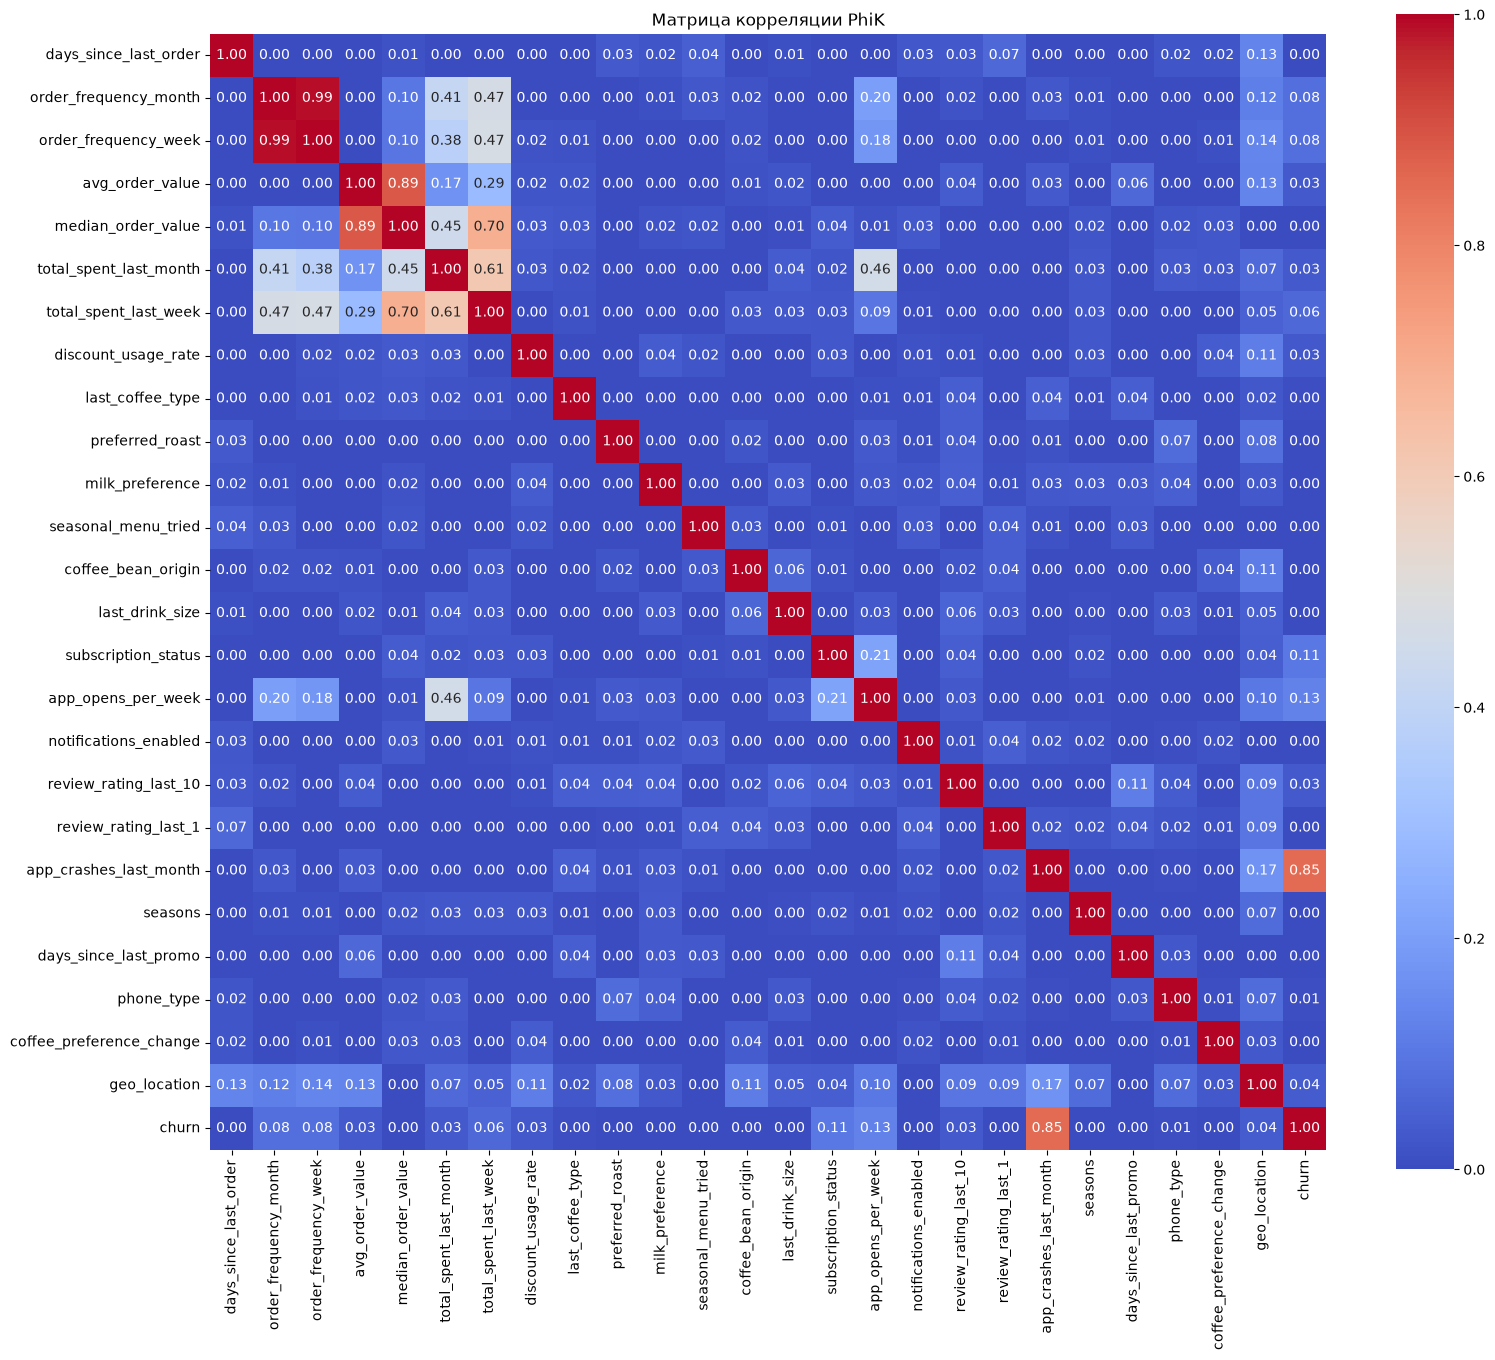

In [14]:
data_for_corr = data.drop(columns='user_id')
phik_corr = data_for_corr.phik_matrix()

plt.figure(figsize=(18, 15))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Матрица корреляции PhiK')
plt.show()

### Анализ результатов корреляции

Для оценки взаимосвязей между признаками была построена матрица корреляции **PhiK**.

Анализ показал, что большинство признаков имеют низкую или умеренную степень взаимосвязи, что свидетельствует об отсутствии выраженной мультиколлинеарности. Наиболее сильная корреляция наблюдается между признаками:

- `order_frequency_month` и `order_frequency_week` (0.99);
- `avg_order_value` и `median_order_value` (0.89).

Данные пары признаков описывают практически одинаковые характеристики поведения пользователя. Использование обоих признаков одновременно может привести к возникновению мультиколлинеарности и снижению интерпретируемости коэффициентов логистической регрессии.

В связи с этим было принято решение удалить следующие признаки:

- `order_frequency_week`;
- `median_order_value`;
- `total_spent_last_week`.

Признак `total_spent_last_week` был удален на основании результатов первоначального анализа данных, поскольку характеризует те же расходы пользователя, что и `total_spent_last_month`, но за более короткий временной интервал. Для дальнейшего анализа был сохранен признак `total_spent_last_month`, содержащий более полную информацию о расходах пользователя.

Стоит отметить, что признак `app_crashes_last_month` имеет наиболее высокую корреляцию с целевой переменной `churn` (0.85), что свидетельствует о его высокой информативности при прогнозировании оттока пользователей.

### Вывод

В ходе предобработки данных был проведен анализ структуры датасета, типов данных, пропущенных значений, категориальных признаков, выбросов и взаимосвязей между признаками.

В процессе анализа были выявлены пропущенные значения практически во всех признаках. Для числовых признаков пропуски были заполнены медианой, для части категориальных признаков — модой или отдельной категорией `Unknown`, а в признаках с небольшим количеством пропусков строки были удалены.

Также были обнаружены некорректные отрицательные значения в ряде числовых признаков, которые были ограничены снизу нулем с помощью `np.clip()`. Для признаков с выраженной правосторонней асимметрией было применено логарифмическое преобразование, что позволило уменьшить влияние экстремальных значений.

Анализ категориальных признаков показал необходимость их последующего кодирования. Для большинства признаков будет использован One-Hot Encoding, а для признака `geo_location`, содержащего большое количество уникальных категорий, — Target Encoding.

На основании матрицы корреляции PhiK были выявлены признаки, содержащие практически одинаковую информацию. Для уменьшения мультиколлинеарности из датасета были удалены признаки `order_frequency_week`, `median_order_value` и `total_spent_last_week`.

В результате была сформирована подготовленная выборка, пригодная для дальнейшего кодирования признаков, разделения на обучающую и тестовую выборки и построения модели логистической регрессии.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [15]:
data = data.dropna(
    subset=[
        'preferred_roast',
        'phone_type',
        'geo_location'
    ]
)

In [16]:
## Разделяем данные на train_val/test
X = data.drop(columns = 'churn').reset_index(drop=True)
y = data['churn'].reset_index(drop=True)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify= y, random_state=RANDOM_STATE)

In [17]:
# Удаление признаков
def drop_columns(X):
    return X.drop(
        columns=[
            'user_id',
            'order_frequency_week',
            'median_order_value'
        ]
    )


# Исправление отрицательных значений
clip_features = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'seasonal_menu_tried',
    'app_opens_per_week',
    'notifications_enabled',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'coffee_preference_change'
]

def clip_values(X):
    X = X.copy()
    cols = [c for c in clip_features if c in X.columns]
    X[cols] = X[cols].clip(lower=0)
    return X


# Логарифмирование
log_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'app_opens_per_week',
    'days_since_last_promo'
]

def log_transform(X):
    X = X.copy()
    cols = [c for c in log_features if c in X.columns]
    X[cols] = np.log1p(X[cols])
    return X

In [18]:
numeric_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

binary_features = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]

In [19]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [20]:
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [21]:
categorical_pipeline = ColumnTransformer(
    transformers=[

        (
            'last_coffee_type',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['last_coffee_type']
        ),

        (
            'preferred_roast',
            OneHotEncoder(handle_unknown='ignore'),
            ['preferred_roast']
        ),

        (
            'milk_preference',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['milk_preference']
        ),

        (
            'coffee_bean_origin',
            Pipeline([
                ('imputer', SimpleImputer(strategy='constant',
                                          fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['coffee_bean_origin']
        ),

        (
            'last_drink_size',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['last_drink_size']
        ),

        (
            'subscription_status',
            Pipeline([
                ('imputer', SimpleImputer(strategy='constant',
                                          fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['subscription_status']
        ),

        (
            'seasons',
            Pipeline([
                ('imputer', SimpleImputer(strategy='constant',
                                          fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            ['seasons']
        ),

        (
            'phone_type',
            OneHotEncoder(handle_unknown='ignore'),
            ['phone_type']
        ),

        (
            'geo_location',
            TargetEncoder(),
            ['geo_location']
        )
    ],
    remainder='drop'
)

In [22]:
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_pipeline, numeric_features),

        ('bin', binary_pipeline, binary_features),

        ('cat', categorical_pipeline, categorical_features)

    ]
)

In [23]:
full_pipeline = Pipeline([

    ('drop_columns',
     FunctionTransformer(drop_columns, validate=False)),

    ('clip',
     FunctionTransformer(clip_values, validate=False)),

    ('log',
     FunctionTransformer(log_transform, validate=False)),

    ('preprocessor', preprocessor)

])

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.